In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
class llm_state(TypedDict):

    prompt:str
    outline:str
    blog:str

In [ ]:
graph = StateGraph(llm_state)


In [4]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(verbose=True)

model = ChatOpenAI(model='gpt-4o-mini')

In [5]:
from langchain_core.output_parsers import StrOutputParser

parser=StrOutputParser()

In [6]:
prompt = f" create a detailed outline for writing a blog on this topic {llm_state['prompt']}"

outline = parser.invoke(model.invoke(prompt))

In [7]:
print(outline)

Certainly! Below is a detailed outline for a blog post centered around the topic suggested by `__main__.llm_state['prompt']`. Since the prompt seems to be related to a technical aspect, possibly about the state of a large language model in a programming context, we can structure the blog post to cover various relevant areas. Here's how you might outline it:

---

### Blog Post Outline: Understanding `__main__.llm_state['prompt']`

#### I. Introduction
   A. Brief introduction to language models (LLMs)
      1. Definition of LLMs
      2. Importance of LLMs in current technology
   B. Explanation of the prompt in LLMs
      1. What is a prompt?
      2. Role of prompts in generating responses
   C. Overview of the blog post structure

#### II. Understanding `__main__.llm_state`
   A. Explanation of the concept of `__main__`
      1. What does `__main__` signify in Python?
      2. Significance in LLM implementation
   B. Breakdown of `llm_state`
      1. Definition of `llm_state`
      

In [8]:
def create_outline(state: llm_state) -> TypedDict:

    prompt = state['prompt']
    outline_prompt = f" create a detailed outline for writing a blog on this topic {prompt}"
    outline = parser.invoke(model.invoke(outline_prompt))
    state['outline'] = outline
    return state


In [9]:
def create_blog(state:llm_state) -> TypedDict:
    outline = state['outline']
    blog_prompt = f" create a detailed blog for this topic {outline}"
    blog = parser.invoke(model.invoke(blog_prompt))

    return state


In [10]:
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START,"create_outline")
graph.add_edge("create_outline","create_blog")
graph.add_edge("create_blog",END)

In [11]:
workflow = graph.compile()

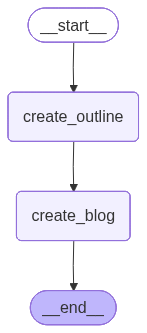

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [13]:
inital_state = {prompt: "how to get tech internships in new delhi"}

final_state = workflow.invoke(inital_state)


print(final_state)





KeyError: 'prompt'